# ***INTRODUCTION***

Building on the general health analysis, this project further stratifies patients into low, medium, and high cardiovascular risk groups using demographic, lifestyle, and clinical features. Predictive modeling, including Random Forest and Logistic Regression algorithms, was applied to estimate individual risk probabilities. The results were visualized through the dashboard, revealing clear patterns of cardiovascular risk across populations. This approach demonstrates how predictive analytics can support early identification of high-risk patients, enabling targeted prevention and informed healthcare decision-making.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

This code cell imports the key libraries needed for data preprocessing, machine learning model training, and evaluation. It uses Scikit-learn pipelines to handle missing values, scale numerical features, encode categorical variables, and train Logistic Regression and Random Forest models.

Model performance is assessed using accuracy, ROC-AUC, precision-recall metrics, and confusion matrices, while permutation importance and Matplotlib are used to interpret and visualize feature impact and results.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


It allows Colab to access files stored in your Drive (such as datasets, notebooks, or saved outputs) by linking them to the path /content/drive. Once mounted, you can read from and write to your Drive directly within Colab as if it were a local folder.

In [3]:
file_path = "/content/drive/MyDrive/Patients Data.csv"

This code mounts Google Drive and loads the patient CSV file into a pandas DataFrame for analysis

In [4]:
df = pd.read_csv(file_path)

This line of code imports a dataset from a CSV file into a pandas DataFrame, making the data available for exploration, cleaning, and analysis within Python.



In [5]:
df.head()

,PatientID,State,Sex,GeneralHealth,Age Category,HeightInMeters,WeightInKilograms,BodyMassIndex(kg/m2),HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,75 - 79,1.63,85,32,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,65 - 69,1.60,72,28,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,60 - 64,1.78,71,23,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,70 - 74,1.78,95,30,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,50 - 54,1.68,78,28,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [6]:
df.shape


(237630, 35)

It returns the dimensions of a DataFrame, specifically (number of rows, number of columns)

In [7]:
df.columns


Index(['PatientID', 'State', 'Sex', 'GeneralHealth', 'Age Category',
       'HeightInMeters', 'WeightInKilograms', 'BodyMassIndex(kg/m2)',
       'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

## Check for missing data

In [ ]:
df.isnull().sum()


,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
Age Category,0
HeightInMeters,0
WeightInKilograms,0
BodyMassIndex(kg/m2),0
HadHeartAttack,0
HadAngina,0


In [ ]:
df['HadHeartAttack'].value_counts()


,count
HadHeartAttack,
0,224429
1,13201


This code counts the number of occurrences of each unique value in the HadHeartAttack column of the DataFrame(df)

In [8]:
X = df.drop(columns=['HadHeartAttack'])
y = df['HadHeartAttack']


This code separates the dataset into features (X) and target (y) for modeling:

X contains all columns except HadHeartAttack (input variables).

y contains only HadHeartAttack (the output variable to predict).

In [9]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns


This code separates the columns in the dataset X by their data type:


numeric_features stores the names of all numeric columns (int64 and float64).


categorical_features stores the names of all categorical columns (object).


It’s useful for applying different preprocessing steps to numeric and categorical data.


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


This code splits the dataset into training and testing sets. X contains the features and y the target. 20% of the data goes to the test set (test_size=0.2). stratify=y ensures the target class distribution is preserved in both sets. random_state=42 makes the split reproducible.

In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


This code defines a pipeline for numeric data preprocessing:

SimpleImputer(strategy='median') → fills missing values with the median of each column.

StandardScaler() → standardizes features by removing the mean and scaling to unit variance.

So, any numeric data passed through numeric_transformer will first have missing values filled and then be scaled.

In [12]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


This code creates a pipeline to preprocess categorical features:

SimpleImputer fills any missing values with the string 'Missing'.

OneHotEncoder converts categorical values into one-hot encoded columns, ignoring any unseen categories during transformation and outputting a dense array.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


it automatically handles numeric and categorical columns separately in a single pipeline for machine learning.

In [14]:
from sklearn.ensemble import RandomForestClassifier


This line imports the RandomForestClassifier from scikit-learn’s ensemble module, which is a machine learning model that builds multiple decision trees and combines their predictions to classify data, improving accuracy and reducing overfitting.

In [15]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)


This code creates a Random Forest classifier with 200 trees, a maximum depth of 12, balanced class weights to handle class imbalance, a fixed random seed for reproducibility, and uses all CPU cores for parallel processing.

In [16]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])


This code creates a scikit-learn pipeline that sequentially applies two steps:

preprocessor – handles data preprocessing (e.g., scaling, encoding, imputing).

model – applies a machine learning model for training or prediction.

It allows you to combine preprocessing and modeling into a single, streamlined workflow.

In [17]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['PatientID', 'HeightInMeters', 'WeightInKilograms',
       'BodyMassIndex(kg/m2)', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'Had...
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['State', 'Sex', 'GeneralHealth', 'Age Category', 'HadDiabetes',
       'SmokerStatus', 'ECigaretteUsage', 'RaceEthnicityCategory',
       'TetanusLast10Tdap'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

This code trains (fits) the machine learning pipeline on the training data X_train (features) and y_train (target), applying all preprocessing steps and learning the model parameters.

In [18]:
risk_probabilities = pipeline.predict_proba(X_test)[:, 1]


This code calculates the predicted probability of the positive class ( "HadHeartAttack = 1") for each sample in X_test using a trained pipeline.

pipeline.predict_proba(X_test) returns probabilities for both classes (0 and 1).

[:, 1] selects only the probability of the positive class.

risk_probabilities stores these probabilities.

In [19]:
def risk_group(p):
    if p < 0.30:
        return 'Low Risk'
    elif p < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_groups = pd.Series(risk_probabilities).apply(risk_group)


This code categorizes patients into risk groups based on their predicted probabilities (risk_probabilities):

< 0.30 → Low Risk

0.30–0.59 → Medium Risk

≥ 0.60 → High Risk

It applies the risk_group function to each probability and stores the results in a Pandas Series risk_groups.

In [20]:
from sklearn.metrics import roc_auc_score, classification_report


This code imports two functions from sklearn.metrics:

roc_auc_score: Measures the area under the ROC curve, evaluating the model's ability to distinguish between classes.

classification_report: Generates a text summary of key classification metrics like precision, recall, F1-score, and support.

In [21]:
roc_auc_score(y_test, risk_probabilities)


np.float64(0.8801038810103441)

This code evaluates model classification performance, with 1 = perfect, 0.5 = random guessing.

In [22]:
print(classification_report(y_test, pipeline.predict(X_test)))


              precision    recall  f1-score   support

           0       0.98      0.86      0.92     44886
           1       0.23      0.71      0.35      2640

    accuracy                           0.85     47526
   macro avg       0.61      0.79      0.64     47526
weighted avg       0.94      0.85      0.89     47526



This code evaluates the performance of a trained machine learning model (pipeline) on the test data (X_test, y_test) by generating a classification report that shows precision, recall, F1-score, and support for each class.

In [23]:
results = X_test.copy()
results['Actual_HeartAttack'] = y_test.values
results['Predicted_Risk_Probability'] = risk_probabilities
results['Predicted_Risk_Group'] = risk_groups.values

results.head()


,PatientID,State,Sex,GeneralHealth,Age Category,HeightInMeters,WeightInKilograms,BodyMassIndex(kg/m2),HadAngina,HadStroke,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,Actual_HeartAttack,Predicted_Risk_Probability,Predicted_Risk_Group
89910,89911,Maryland,Female,Poor,60 - 64,1.57,109,44,0,0,...,0,0,0,1,"Yes, received Tdap",0,0,1,0.491679,Medium Risk
65554,65555,Iowa,Male,Very good,65 - 69,1.83,86,26,0,1,...,1,0,1,0,"Yes, received tetanus shot but not sure what type",0,0,0,0.514284,Medium Risk
824,825,Alabama,Female,Very good,80 or older,1.73,76,26,0,0,...,1,0,1,1,"No, did not receive any tetanus shot in the pa...",0,0,0,0.326038,Medium Risk
190170,190171,Texas,Male,Very good,40 - 44,1.75,127,41,0,0,...,1,0,0,0,"No, did not receive any tetanus shot in the pa...",0,0,0,0.118640,Low Risk
89014,89015,Maryland,Female,Good,65 - 69,1.63,45,17,0,0,...,1,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1,0,0.418751,Medium Risk


This code creates a new DataFrame results by copying X_test and adds three columns: the actual heart attack outcomes (Actual_HeartAttack), the predicted probabilities of risk (Predicted_Risk_Probability), and the predicted risk group (Predicted_Risk_Group). It then displays the first few rows with head()

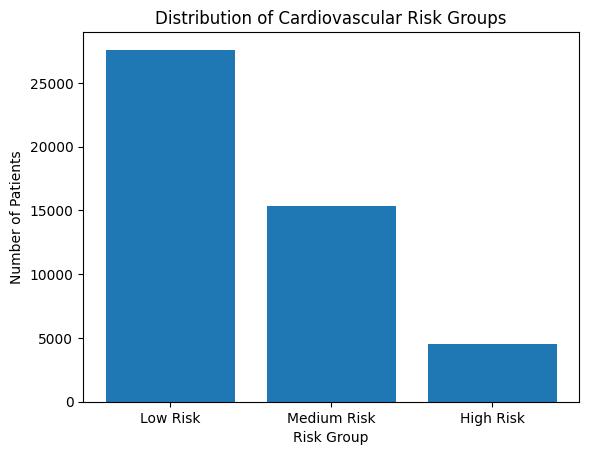

In [24]:
import matplotlib.pyplot as plt

risk_counts = results['Predicted_Risk_Group'].value_counts()

plt.figure()
plt.bar(risk_counts.index, risk_counts.values)
plt.xlabel("Risk Group")
plt.ylabel("Number of Patients")
plt.title("Distribution of Cardiovascular Risk Groups")
plt.show()


This code creates a bar chart showing the number of patients in each predicted cardiovascular risk group from the results DataFrame. It counts the occurrences of each Predicted_Risk_Group, then plots them with labeled axes and a title.

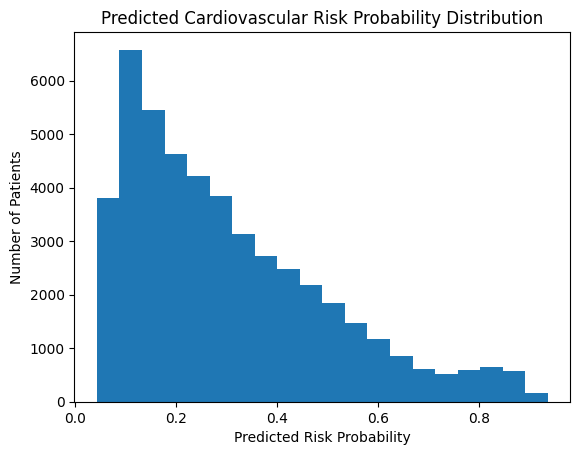

In [25]:
plt.figure()
plt.hist(results['Predicted_Risk_Probability'], bins=20)
plt.xlabel("Predicted Risk Probability")
plt.ylabel("Number of Patients")
plt.title("Predicted Cardiovascular Risk Probability Distribution")
plt.show()


This code creates a histogram showing the distribution of predicted cardiovascular risk probabilities for patients. It divides the Predicted_Risk_Probability values into 20 bins, labels the axes, adds a title, and displays the plot.

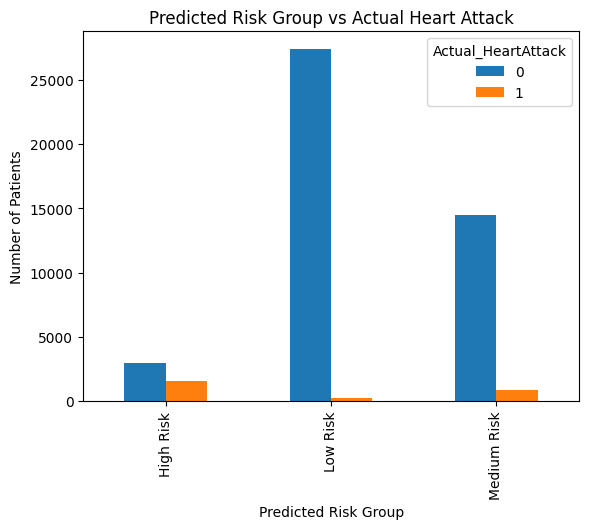

In [26]:
import pandas as pd

summary = pd.crosstab(
    results['Predicted_Risk_Group'],
    results['Actual_HeartAttack']
)

summary.plot(kind='bar')
plt.xlabel("Predicted Risk Group")
plt.ylabel("Number of Patients")
plt.title("Predicted Risk Group vs Actual Heart Attack")
plt.show()


This code creates a bar chart comparing predicted risk groups to actual heart attack occurrences. It first uses pd.crosstab to count patients in each combination of predicted vs actual values, then plots these counts with labeled axes and a title.

# ***LIMITATIONS***

The dataset is cross-sectional, capturing patient information at a single point in time, which limits the ability to track disease progression over time.

Heart attack status reflects historical events, so the analysis cannot directly predict future occurrences.

Certain clinical variables, such as direct heart rate measurements or longitudinal lab results, were unavailable, which may reduce prediction accuracy.

Demographic representation in the dataset may introduce biases, affecting the generalizability of the model across populations.

# ***RECOMMENDATION***

Collecting longitudinal data would improve understanding of disease progression and enhance predictive performance.

Including additional clinical variables such as heart rate trends, lab results, and blood pressure measurements could strengthen risk stratification.

Expanding data to include a more diverse patient population will improve model generalizability.

Integrating the predictive model into clinical decision support tools can aid healthcare providers in early intervention for high-risk patients.

# ***CONCLUSION***

This analysis highlights patterns of cardiovascular risk across populations and demonstrates the value of predictive analytics in healthcare. Despite limitations related to cross-sectional data and missing clinical variables, the models provide actionable insights for early identification of high-risk patients. Future integration of richer, longitudinal data and broader clinical features can enhance predictive accuracy, supporting proactive prevention and improved patient outcomes.